<a href="https://colab.research.google.com/github/edsonportosilva/OptiCommPy/blob/main/examples/basic_OOK_transmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulate a basic OOK transmission system

In [1]:
if 'google.colab' in str(get_ipython()):    
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install . 

In [2]:
import numpy as np
from optic.models.devices import mzm, photodiode, edfa
from optic.models.channels import linearFiberChannel
from optic.comm.modulation import modulateGray
from optic.comm.sources import bitSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W
from optic.plot import eyediagram
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp

c:\Users\edson\.conda\envs\opticommpy-env\Lib\site-packages\cupyx\jit\_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [3]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [4]:
figsize(10, 3)

In [5]:
np.random.seed(seed=123) # fixing the seed to get reproducible results

### Intensity modulation (IM) with On-Off Keying (OOK)

Average power of the modulated optical signal [mW]: 0.50 mW
Average power of the modulated optical signal [dBm]: -3.01 dBm


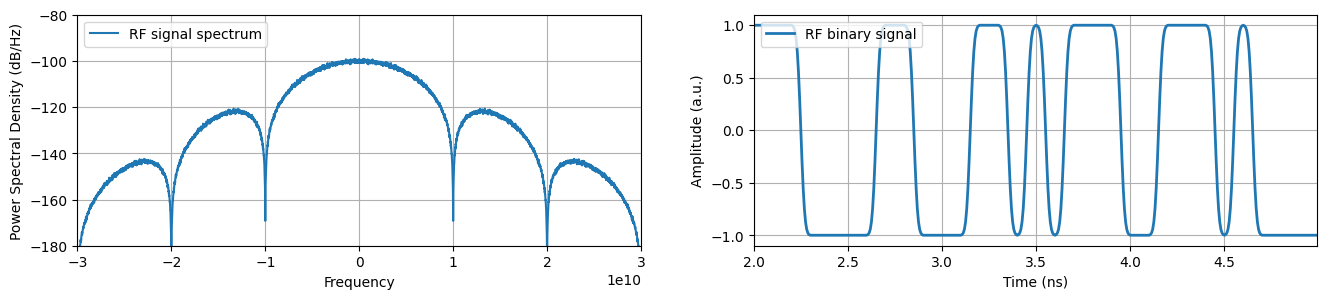

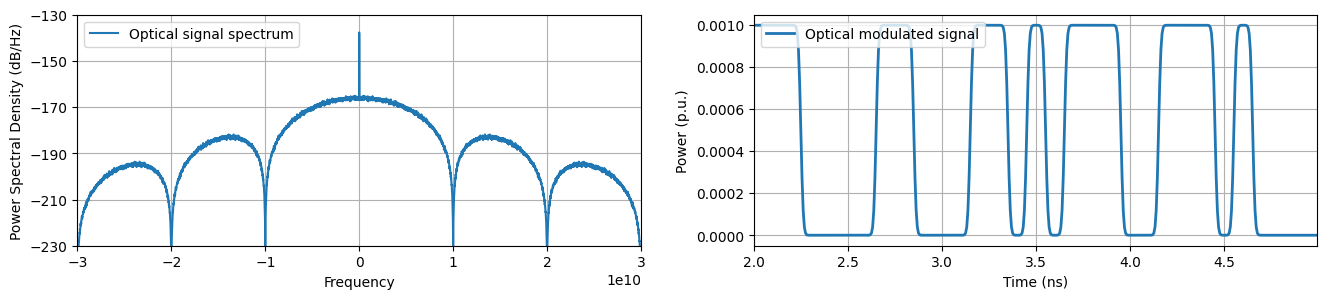

In [6]:
# simulation parameters
SpS = 16     # samples per symbol
M = 2        # order of the modulation format
Rs = 10e9    # Symbol rate (for OOK case Rs = Rb)
Fs = Rs*SpS  # Sampling frequency
Ts = 1/Fs    # Sampling period

# Laser power
Pi_dBm = 0         # laser optical power at the input of the MZM in dBm
Pi = dBm2W(Pi_dBm) # convert from dBm to W

# Bit source parameters
paramBits = parameters()
paramBits.nBits = 100000  # number of bits to be generated
paramBits.mode = 'prbs'   # mode of the bit source  
paramBits.order = 23      # order of the PRBS
paramBits.seed = 12335    # seed for the random number generator

# pulse shaping parameters
paramPulse = parameters()
paramPulse.pulseType = 'nrz'  # pulse shape type
paramPulse.SpS = SpS     # samples per symbol

# MZM parameters
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = -paramMZM.Vpi/2

# generate pseudo-random bit sequence
bitsTx = bitSource(paramBits)

# generate 2-PAM modulated symbol sequence
symbTx = modulateGray(bitsTx, M, 'pam')    
symbTx = pnorm(symbTx) # power normalization

# upsampling
symbolsUp = upsample(symbTx, SpS)

# pulse shaping
pulse = pulseShape(paramPulse)
sigTx = firFilter(pulse, symbolsUp)

sigTx = anorm(sigTx)  # power normalization

# optical modulation
Ai = np.sqrt(Pi)
sigTxo = mzm(Ai, sigTx, paramMZM)

print('Average power of the modulated optical signal [mW]: %.2f mW'%(signalPower(sigTxo)/1e-3))
print('Average power of the modulated optical signal [dBm]: %.2f dBm'%(10*np.log10(signalPower(sigTxo)/1e-3)))

fig, axs = plt.subplots(1, 2, figsize=(16,3))
interval = np.arange(16*20,16*50)
t = interval*Ts/1e-9

# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-180,-80);
axs[0].psd(sigTx,Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'RF signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, sigTx[interval], label = 'RF binary signal', linewidth=2)
axs[1].set_ylabel('Amplitude (a.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

fig, axs = plt.subplots(1, 2, figsize=(16,3))
# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-230,-130);
axs[0].psd(np.abs(sigTxo)**2, Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, np.abs(sigTxo[interval])**2, label = 'Optical modulated signal', linewidth=2)
axs[1].set_ylabel('Power (p.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

### Linear fiber channel model (fiber + EDFA opt. amplifier)

In [7]:
# linear optical channel
paramCh = parameters()
paramCh.L = 100         # total link distance [km]
paramCh.α = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16         # fiber dispersion parameter [ps/nm/km]
paramCh.Fc = 193.1e12  # central optical frequency [Hz]
paramCh.Fs = Fs        # simulation sampling frequency [samples/second]

sigCh = linearFiberChannel(sigTxo, paramCh)

# receiver pre-amplifier
paramEDFA = parameters()
paramEDFA.G = paramCh.α*paramCh.L    # edfa gain
paramEDFA.NF = 4.5   # edfa noise figure 
paramEDFA.Fc = paramCh.Fc
paramEDFA.Fs = Fs

sigCh = edfa(sigCh, paramEDFA)

### Direct-detection (DD) pin receiver model

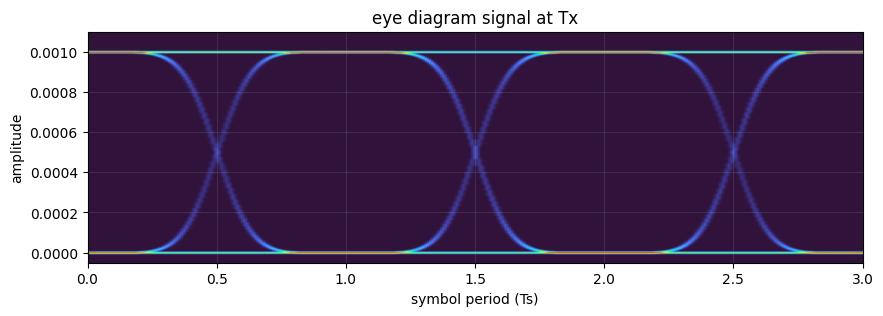

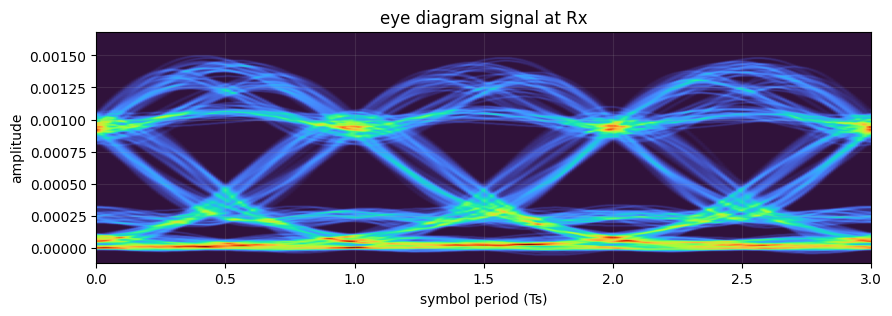

In [8]:
# ideal photodiode (noiseless, no bandwidth limitation)
paramPD = parameters()
paramPD.ideal = True
paramPD.Fs = Fs

I_Tx = photodiode(sigTxo, paramPD) # transmitted signal

# noisy photodiode (thermal noise + shot noise + bandwidth limitation)
paramPD = parameters()
paramPD.ideal = False
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ipd_sat = 5e-3

I_Rx = photodiode(sigCh, paramPD) # received signal after fiber channel and non-ideal PD

discard = 50*SpS  # number of samples to discard at the beginning and end of the signal for eye diagram
eyediagram(I_Tx[discard:-discard], I_Tx.size-2*discard, SpS, plotlabel='signal at Tx', ptype='fancy')
eyediagram(I_Rx[discard:-discard], I_Rx.size-2*discard, SpS, plotlabel='signal at Rx', ptype='fancy')

I0 = 0.22 
I1 = 2.12 
σ0 = 0.22 
σ1 = 0.12 
Optimal decision threshold Id = 1.44 
Q = 5.60 

Number of counted errors = 0 
BER = 0.00e+00 
Pb = 1.10e-08 


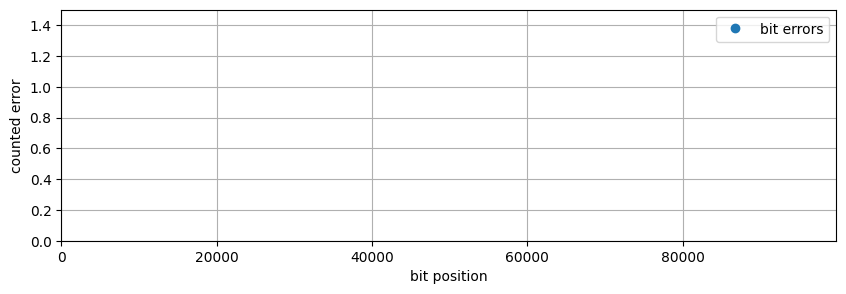

In [9]:
I_Rx = I_Rx/np.std(I_Rx)

# capture samples in the middle of signaling intervals
I_Rx = I_Rx[0::SpS]

# get received signal statistics
I1 = np.mean(I_Rx[bitsTx==1]) # average value of I1
I0 = np.mean(I_Rx[bitsTx==0]) # average value of I0

σ1 = np.std(I_Rx[bitsTx==1]) # standard deviation σ1 of I1
σ0 = np.std(I_Rx[bitsTx==0]) # standard deviation σ0 of I0

Id = (σ1*I0 + σ0*I1)/(σ1 + σ0) # optimal decision threshold
Q = (I1-I0)/(σ1 + σ0) # factor Q

print('I0 = %.2f '%(I0))
print('I1 = %.2f '%(I1))
print('σ0 = %.2f '%(σ0))
print('σ1 = %.2f '%(σ1))
print('Optimal decision threshold Id = %.2f '%(Id))
print('Q = %.2f \n'%(Q))

# Apply the optimal decision rule
bitsRx = np.empty(bitsTx.size)
bitsRx[I_Rx> Id] = 1
bitsRx[I_Rx<= Id] = 0

discard = 100
err = np.logical_xor(bitsRx[discard:bitsRx.size-discard], bitsTx[discard:bitsTx.size-discard])
BER = np.mean(err)

Pb = 0.5*erfc(Q/np.sqrt(2)) # theoretical error probability
print('Number of counted errors = %d '%(err.sum()))
print('BER = %.2e '%(BER))
print('Pb = %.2e '%(Pb))

err = err*1.0
err[err==0] = np.nan

plt.plot(err,'o', label = 'bit errors')
plt.vlines(np.where(err>0), 0, 1)
plt.xlabel('bit position')
plt.ylabel('counted error')
plt.legend()
plt.grid()
plt.ylim(0, 1.5)
plt.xlim(0,err.size);

### Generate curve of BER vs receiver input power

In [10]:
# simulation parameters
SpS = 16        # Samples per symbol
M = 2           # order of the modulation format
Rs = 40e9       # Symbol rate (for the OOK case, Rs = Rb)
Fs = SpS*Rs     # Signal sampling frequency (samples/second)
Ts = 1/Fs       # Sampling period

# Bit source parameters
paramBits = parameters()
paramBits.nBits = 100000  # number of bits to be generated
paramBits.mode = 'prbs'   # mode of the bit source  
paramBits.order = 23      # order of the PRBS

# pulse shaping parameters
paramPulse = parameters()
paramPulse.pulseType = 'nrz'  # pulse shape type
paramPulse.SpS = SpS         # samples per symbol

# MZM parameters
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = -paramMZM.Vpi/2

# NRZ pulse shape
pulse = pulseShape(paramPulse)

# photodiode parameters
paramPD = parameters()
paramPD.ideal = False
paramPD.B = 1.1*Rs
paramPD.Fs = Fs
   
powerValues = np.arange(-30,-14) # power values at the input of the pin receiver
BER = np.zeros(powerValues.shape)
Pb = np.zeros(powerValues.shape)

discard = 100
for indPi, Pi_dBm in enumerate(tqdm(powerValues)):
    
    Pi = dBm2W(Pi_dBm+3) # optical signal power in W at the MZM input

    # generate pseudo-random bit sequence   
    paramBits.seed = 12335 + indPi    # seed for the random number generator 
    bitsTx = bitSource(paramBits)
    n = np.arange(0, bitsTx.size)

    # generate ook modulated symbol sequence
    symbTx = modulateGray(bitsTx, M, 'pam')    
    symbTx = pnorm(symbTx) # power normalization

    # upsampling
    symbolsUp = upsample(symbTx, SpS)

    # pulse formatting
    sigTx = firFilter(pulse, symbolsUp)
    sigTx = anorm(sigTx)

    # optical modulation
    Ai = np.sqrt(Pi)
    sigTxo = mzm(Ai, sigTx, paramMZM)

    # pin receiver
    I_Rx = photodiode(sigTxo, paramPD)
    I_Rx = I_Rx/np.std(I_Rx)

    # capture samples in the middle of signaling intervals
    I_Rx = I_Rx[0::SpS]

    # get received signal statistics

    I1 = np.mean(I_Rx[bitsTx==1]) # average value of I1
    I0 = np.mean(I_Rx[bitsTx==0]) # average value of I0

    σ1 = np.std(I_Rx[bitsTx==1]) # standard deviation σ1 of I1
    σ0 = np.std(I_Rx[bitsTx==0]) # standard deviation σ0 of I0

    Id = (σ1*I0 + σ0*I1)/(σ1 + σ0) # optimal decision threshold
    Q = (I1-I0)/(σ1 + σ0) # Q-factor

    # Aplica a regra de decisão ótima
    bitsRx = np.empty(bitsTx.size)
    bitsRx[I_Rx>  Id] = 1
    bitsRx[I_Rx<= Id] = 0

    err = np.logical_xor(bitsRx[discard:bitsRx.size-discard], bitsTx[discard:bitsTx.size-discard])
    BER[indPi] = np.mean(err)
    Pb[indPi] = 0.5*erfc(Q/np.sqrt(2)) # probability of bit error (theory)

  0%|          | 0/16 [00:00<?, ?it/s]

C:\Users\edson\AppData\Local\Temp\ipykernel_52336\1570430707.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(powerValues, np.log10(BER),'o',label='BER')


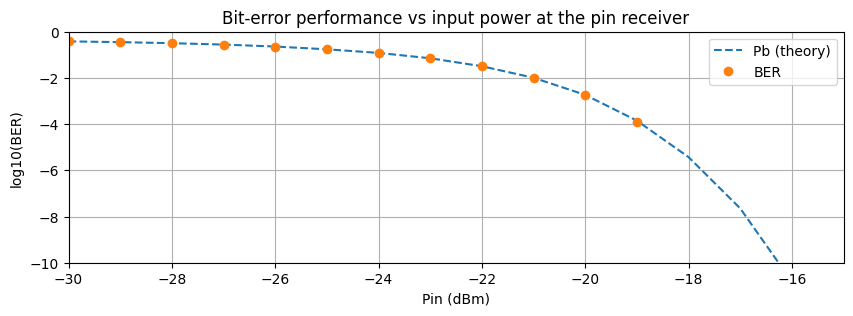

In [11]:
plt.figure()
plt.plot(powerValues, np.log10(Pb),'--',label='Pb (theory)')
plt.plot(powerValues, np.log10(BER),'o',label='BER')
plt.grid()
plt.ylabel('log10(BER)')
plt.xlabel('Pin (dBm)');
plt.title('Bit-error performance vs input power at the pin receiver')
plt.legend();
plt.ylim(-10,0);
plt.xlim(min(powerValues), max(powerValues));